# 量子・古典ハイブリッド機械学習

量子・古典ハイブリッド機械学習は、量子コンピュータを用いた機械学習のためのNISQアルゴリズムの一種です。  
名前が示す通り、量子コンピュータと古典コンピュータをハイブリッドに利用します。

基本的な考え方はVQEやQAOAと同じです。  
量子コンピュータと古典コンピュータを交互に動作させ、量子回路が持つパラメータ$\theta$を繰り返し更新することで、対象とする量を最小化(最大化)します。
更新後のパラメータを求める計算は古典コンピュータが行います。

古典コンピュータで可能な計算は古典コンピュータ側で行い、パラメータを古典データとして保持することで、量子回路を繰り返し初期化・実行することができます。
これにより量子回路のサイズを小さく抑えることができ、NISQデバイスでの実行に適したものとなります。

VQEやQAOAでは問題に対応するハミルトニアンを定義し、そのハミルトニアンの期待値が最小(最大)になるように量子回路のパラメータを更新していました。一方、量子・古典ハイブリッド機械学習では、量子回路の測定結果を引数とする損失関数を古典コンピュータ側で定義します。
後処理として、古典コンピュータが損失関数の出力を計算し、それを最小化するようにパラメータを更新します。  
これによりハミルトニアンを定義する必要がなくなり、機械学習で広く使われている損失関数をそのまま適用できるようになります。

量子コンピュータ上で動作する量子回路は、大きく3つの部分に分けられます。

まず「データエンコーディング」層で、学習用の入力データを量子回路に埋め込みます。  
次に「パラメトリック量子回路」層は、量子ビットをエンタングルさせる2量子ビットゲートと、パラメータを更新するための回転ゲートの組み合わせで構成されます。この部分でパラメータの更新を通じてモデルの確率分布が学習されます。  
最後に「測定」層で量子状態を測定し、測定結果を古典コンピュータに渡します。

量子回路のパラメータ$\theta$を学習することは、通常のニューラルネットワークにおける重みパラメータの学習と似ています。  
そのため、学習をうまく進めるために必要な要素も、ニューラルネットワークの場合と同様に、例えば次のようなものが挙げられます。

1. データの埋め込み方法
2. 損失関数の設計
3. パラメータの更新方法
4. パラメトリック量子回路(学習層)の設計

それぞれについて様々な手法が提案・利用されています。  
以降のチュートリアルでは、具体的なモデルを用いたシンプルな学習例をいくつか紹介します。

### 参考文献

Benedetti, Marcello, et al. "Parameterized quantum circuits as machine learning models." Quantum Science and Technology 4.4 (2019): 043001.

## 数値微分
関数$f(x)$と微小変化$h$から、数値的に微分係数を求めることができます。

$$
\frac{df(x)}{dx} = \lim_{h \rightarrow 0}\frac{f(x+h) - f(x)}{h}
$$

例えば$f(x) = x^2$、$h=0.1$のとき、$x=1$における微分係数は以下のようになります

In [1]:
x = 1
h = 0.1
((x+h)**2 - x**2) / h

2.100000000000002

## 偏微分
NISQでよく使われるパラメトリック量子回路では、回路中の変数パラメータとして多くの角度が現れます。  
偏微分を使うことで、特定のパラメータにおける微分係数を求めることができます。

$f(x, y)$の$x$についての偏微分。

$$
\frac{\partial f(x,y)}{\partial x}
$$

$f(x, y)$の$y$についての偏微分。

$$
\frac{\partial f(x,y)}{\partial y}
$$

## 勾配
勾配とは、各パラメータについての偏微分をベクトルの形で並べたものです。

$$
(\frac{\partial f(x,y)}{\partial x},\frac{\partial f(x,y)}{\partial y})
$$

勾配は、関数が最小値をとる点(極小点)を見つけるのに役立ちます。  
極小点では微分係数が0になり、その周辺(近傍)では正または負の傾きを持ちます。

- 現在地の座標が極小点より大きい場合、傾きは正になります。したがって、現在地の座標から傾きを引くことで極小点に近づきます。
- 現在地の座標が極小点より小さい場合、傾きは負になります。この場合も同様に、現在地の座標から傾きを引くことで極小点に近づきます。

以上のことから、勾配を使って現在地を更新していくことで極小点を見つけることができます。ここで$e$は学習率を表します。

$$
x' = x -e\cdot\frac{\partial f(x,y)}{\partial x}\\
y' = y -e\cdot\frac{\partial f(x,y)}{\partial y}
$$

このプロセスを繰り返します。

## 勾配降下法
RYゲートを使った回路でVQEを試し、測定の期待値が最小となるパラメータを求めてみましょう。

tensor(3.1411, dtype=torch.float64)


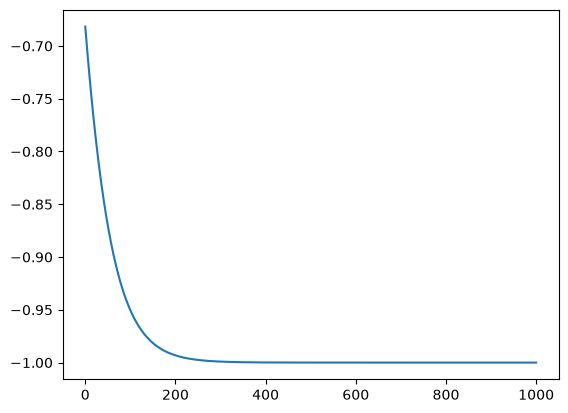

In [2]:
from blueqat import Circuit
from blueqat.utils import Z
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# Z expectation value
def exptZ(a):
    return Circuit().ry(a)[0].run(hamiltonian=1*Z[0])

# Initail setting
ainit = [np.random.rand()*2*np.pi]
a = ainit.copy()
h = 0.001
e = 0.01

# Update and logging of gradient
for i in range(1000):
    a.append(a[i] - e*(exptZ(a[i]+h) - exptZ(a[i]))/h)

# Last value
print(a[-1])

# Plot expectation value
plt.plot(list(map(exptZ, a)))
plt.show()

1量子ビットの$Z$測定の期待値は、状態が$\lvert 1\rangle$のときに最小になります。  
期待値を最小化した結果、$RY$ゲートの回転角はおよそ$\pi = 3.14...$となり、これは初期状態$\lvert 0\rangle$を$\lvert 1\rangle$に変化させる角度です。  
以上より、VQEに成功したことが分かります。

## パラメータシフト則

参考文献: arXiv:1803.00745 [quant-ph] (https://arxiv.org/abs/1803.00745)

微小な数値$h$を用いる数値微分は、実機の量子コンピュータ上で実行する際に問題があります。  
量子コンピュータで計算される期待値には、サンプリングやノイズによるばらつきがあります。$h$が小さすぎるとこのばらつきに埋もれてしまい、逆に大きすぎると数値微分が不正確になります。そのため、$h$をハイパーパラメータとして調整する必要があります。

こうした背景から、量子コンピュータ上で勾配を計算する手法についても研究が進められています。  
ここでは代表的な手法である「パラメータシフト則」を説明します。

可観測量$\hat{B}$の期待値$\langle \hat{B}\rangle$を考えます。  
パウリ回転ゲート$U(\theta) = \exp{(-i\theta P)}\ (P\in \{X, Y, Z, I\})$のパラメータ$\theta$について、$\langle \hat{B}\rangle$の勾配は以下のように得られます。

$$\frac{\partial \langle \hat{B}\rangle}{\partial \theta} = \frac{1}{2} \bigl(\langle \hat{B}\rangle_+ - \langle \hat{B}\rangle_- \bigr)$$

$$U(\theta + \frac{\pi}{2}) = \langle \hat{B}\rangle_+$$
$$U(\theta - \frac{\pi}{2}) = \langle \hat{B}\rangle_-$$

つまり、勾配を求めたい各パラメータについて、$+\frac{\pi}{2}$および$-\frac{\pi}{2}$だけずらした量子回路をそれぞれ実行し、期待値を計算するだけで済みます。  
この手法では、微小な変化$h$の代わりに、固定かつ十分に大きなシフト$\pm\frac{\pi}{2}$を使うため、上記の問題を解決できます。

これは$RX(\theta)$ゲート、$RY(\theta)$ゲート、$RZ(\theta)$ゲートなどのパラメータ$\theta$に適用できます。これを2量子ビットのエンタングルゲートと組み合わせることで、一般的な量子・古典ハイブリッド機械学習の回路を構成することができます。

以下は、先ほどの勾配降下法の計算例を、パラメータシフト則を使って再度行った例です。

tensor(3.1416, dtype=torch.float64)


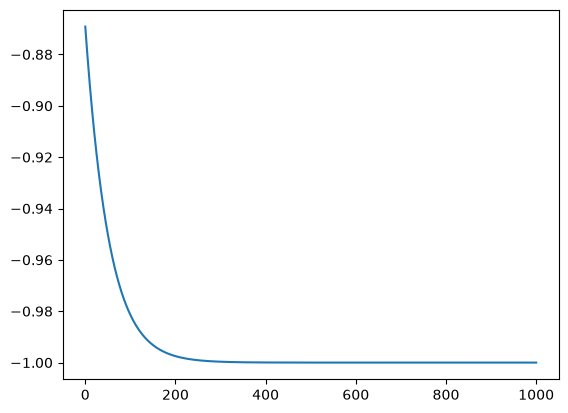

In [3]:
# Initail setting
ainit = [np.random.rand()*2*np.pi]
a = ainit.copy()
e = 0.01

# Update and logging of gradient
for i in range(1000):
    grad = (exptZ(a[i]+np.pi/2) - exptZ(a[i]-np.pi/2)) / 2
    a.append(a[i] - e*grad)

# Last value
print(a[-1])

# Plot expectation value
plt.plot(list(map(exptZ, a)))
plt.show()

## 損失関数
VQEは測定の期待値を最小化しますが、上記のアプローチでは最小化の対象は必ずしも測定の期待値である必要はありません。  
ここではより一般的な損失関数を使ってみます。こうすることで、これを機械学習として捉えることができます。

/var/folders/cd/spczq0r91lnfn5n14s3mfvxr0000gn/T/ipykernel_95058/731499379.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.square(res-tar)


tensor(2.9116, dtype=torch.float64)


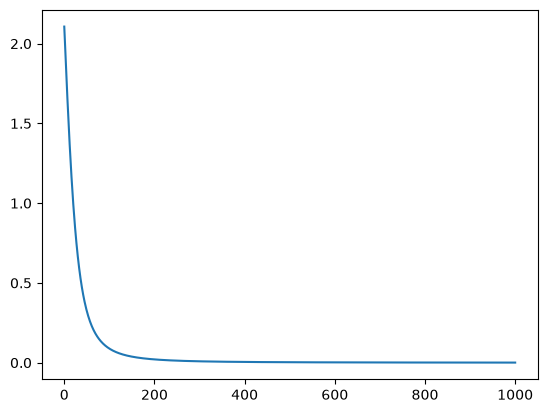

tensor(0.0007, dtype=torch.float64)


In [4]:
from blueqat import Circuit
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# expectation value
def expt(a):
    return Circuit().ry(a)[0].run(hamiltonian=1*Z[0])

# loss function
def loss(res,tar):
    return np.square(res-tar)

# derivative
def dfx(a,h,tgt=-1):
    return (loss(expt(a+h),tgt) - loss(expt(a),tgt))/h
#    return (expt(a+h)-expt(a))/h

# gradient
def grad(a,h,e):
    for i in range(1000):
        a.append(a[i] - e*dfx(a[i],h))
    return a

# initialize
a = [np.random.rand()*2*np.pi]
h = 0.001
e = 0.01

ra = grad(a,h,e)
print(ra[-1])

arr = [loss(expt(i),-1) for i in ra]

plt.plot(arr)
plt.show()

print(arr[-1])

## モーメンタムSGD

/var/folders/cd/spczq0r91lnfn5n14s3mfvxr0000gn/T/ipykernel_95058/731499379.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.square(res-tar)


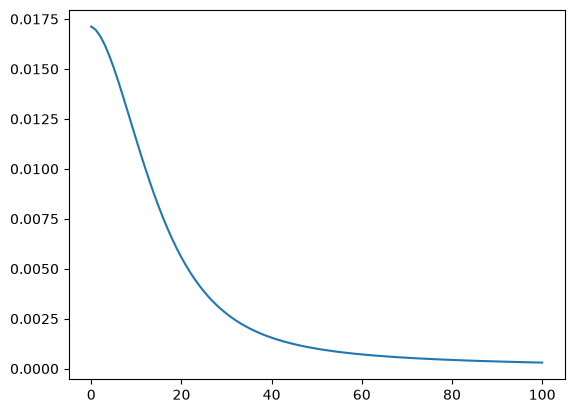

In [5]:
#momentum sgd
def msgd(a,h,e,tgt,alpha):
    p_delta = 0
    for i in range(100):
        update = -e*dfx(a[i],h,tgt) + alpha*p_delta
        a.append(a[i] + update)
        p_delta = update
    return a

#initialization
a = ainit.copy()
h = 0.001
e = 0.01

alpha = 0.9
tgt = -1

result = msgd(a,h,e,tgt,alpha)
arr = [loss(expt(i),tgt) for i in result]

plt.plot(arr)
plt.show()

## Adagrad

/var/folders/cd/spczq0r91lnfn5n14s3mfvxr0000gn/T/ipykernel_95058/731499379.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.square(res-tar)
/var/folders/cd/spczq0r91lnfn5n14s3mfvxr0000gn/T/ipykernel_95058/1877547063.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  update = -e/np.sqrt(G)*g


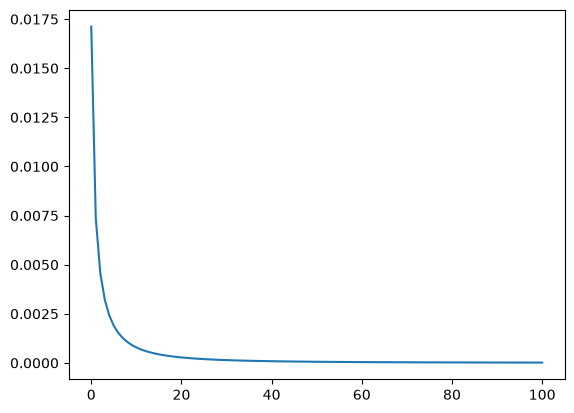

In [6]:
def adagrad(a,h,e,tgt,epsilon):
    G = epsilon
    for i in range(100):
        g = dfx(a[i],h,tgt)
        G += g*g
        update = -e/np.sqrt(G)*g
        a.append(a[i] + update)
    return a

#initialization
a = ainit.copy()
h = 0.001
e = 0.1
epsilon = 1e-08
tgt = -1

result = adagrad(a,h,e,tgt,epsilon)
arr = [loss(expt(i),tgt) for i in result]

plt.plot(arr)
plt.show()